--- 3. Sample Data (First 5 Rows) ---
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


--- Data Preprocessing Complete ---
--- 4. EDA: Target Distribution ---


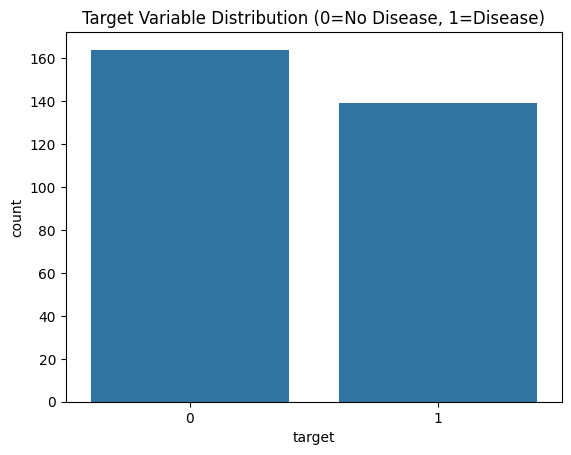

--- 4. EDA: Correlation Heatmap ---


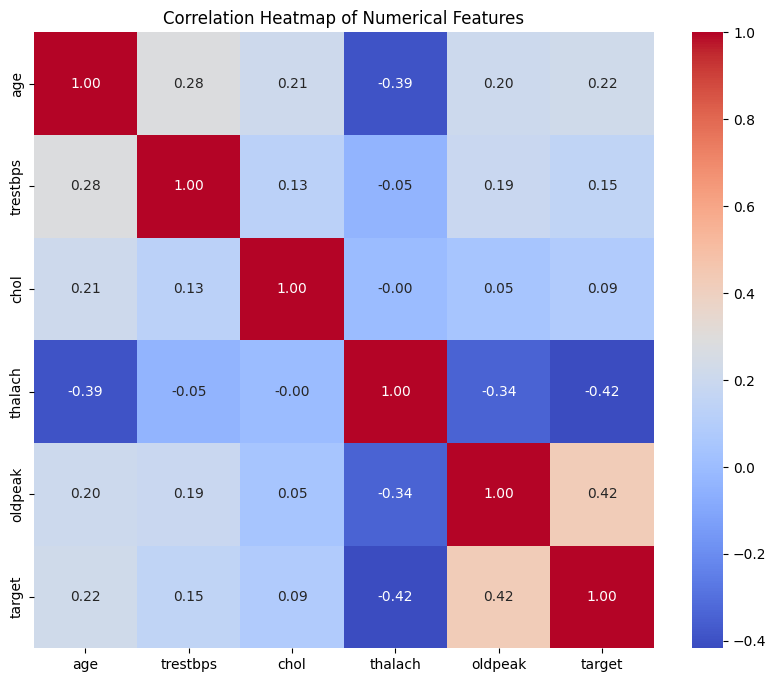

--- 3 Ensemble Models Defined Successfully ---
--- Starting Model Training & Evaluation ---
Training Gradient Boosting...
Running Cross-Validation for Gradient Boosting...
Finished Gradient Boosting.

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Running Cross-Validation for XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:29:10] WARNING: /w

Finished XGBoost.

Training Stacking (RF+SVM)...
Running Cross-Validation for Stacking (RF+SVM)...
Finished Stacking (RF+SVM).

--- 10. Final Model Comparison Table ---
                   Test Accuracy  Test F1-Score  Test ROC-AUC  \
Stacking (RF+SVM)       0.885246       0.888889      0.937500   
Gradient Boosting       0.852459       0.857143      0.920259   
XGBoost                 0.836066       0.843750      0.890086   

                   CV-5 Mean Accuracy  CV-5 Std Dev  
Stacking (RF+SVM)            0.834609      0.026602  
Gradient Boosting            0.777041      0.025712  
XGBoost                      0.805612      0.064700  

--- Detailed Report for Best Model (Stacking (RF+SVM)) ---
              precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.8

/tmp/ipython-input-1858678365.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


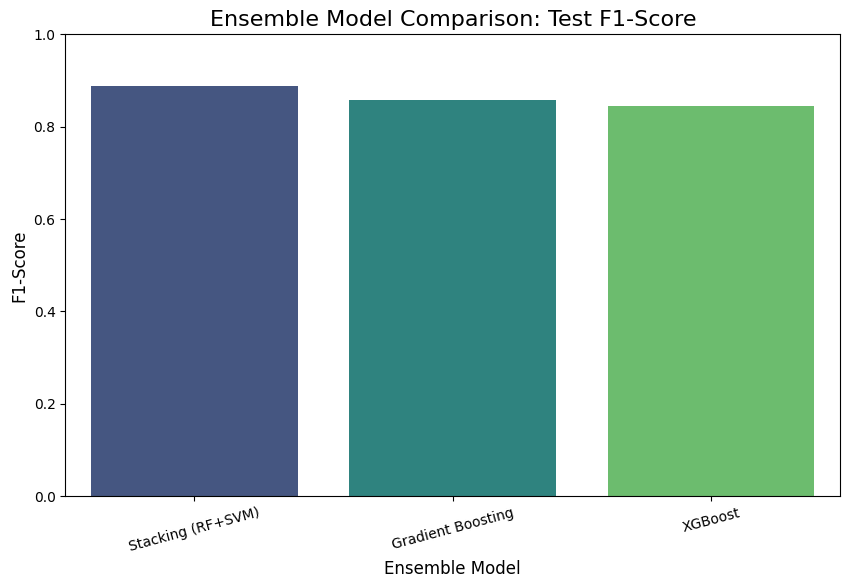

/tmp/ipython-input-1858678365.py:243: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


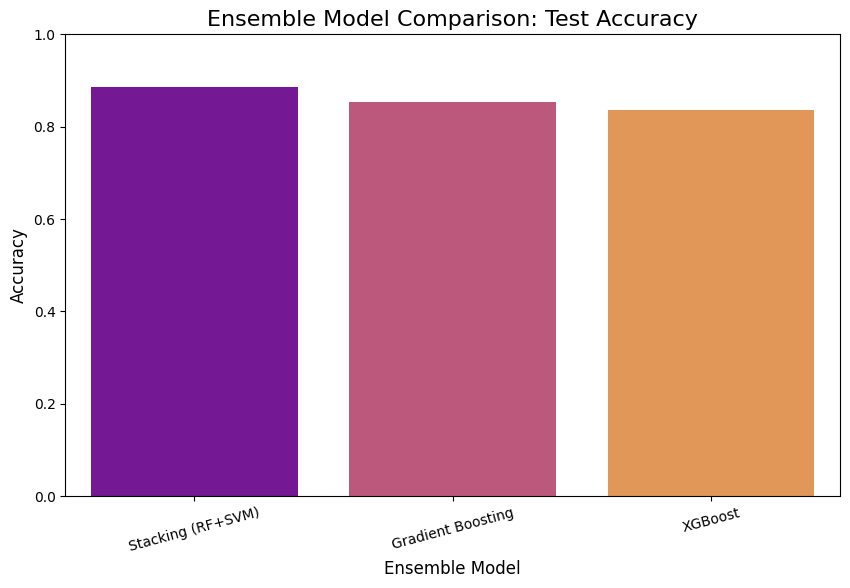


--- SCRIPT COMPLETE ---


In [1]:
# --- 0. SETUP AND IMPORTS ---

# Install xgboost
!pip install xgboost

# Core Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # For saving our model

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# --- 1. & 2. PROBLEM DEFINITION & DATA COLLECTION ---

# Column names from the dataset documentation
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the dataset from the URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None, names=col_names)

print("--- 3. Sample Data (First 5 Rows) ---")
print(df.head())
print("\n")


# --- 3. DATA PREPROCESSING ---

# 1. Handle missing values (marked as '?')
df.replace('?', np.nan, inplace=True)

# 2. Convert target variable to binary (0 = no disease, 1 = presence of disease)
df['target'] = df['target'].apply(lambda x: 1 if int(x) > 0 else 0)

# 3. Define feature types
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 4. Create preprocessing pipelines
# For numerical features: Impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features: Impute with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Bundle preprocessing with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Split dataset
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Preprocessing Complete ---")


# --- 4. EXPLORATORY DATA ANALYSIS (EDA) ---

# 1. Visualize target variable distribution
print("--- 4. EDA: Target Distribution ---")
sns.countplot(x='target', data=df)
plt.title('Target Variable Distribution (0=No Disease, 1=Disease)')
plt.show()

# 2. Visualize correlations (heatmap)
# First, convert numerical columns to numeric type
df[numerical_features] = df[numerical_features].apply(pd.to_numeric)

# Now, create the correlation matrix
print("--- 4. EDA: Correlation Heatmap ---")
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_features + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


# --- 5. & 6. MODEL SELECTION & ENSEMBLE TECHNIQUE ---

# --- Model 1: Gradient Boosting ---
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# --- Model 2: XGBoost ---
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# --- Model 3: Stacking ---
# Define base learners (the "specialists")
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)) # probability=True is needed for ROC-AUC
]

# Define meta-learner (the "manager")
meta_learner = LogisticRegression()

# Create the Stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5 # Use 5-fold cross-validation to train the meta-learner
)

# Bundle into a final pipeline
stacking_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_classifier)
])

# --- Create a dictionary of models for easy iteration ---
models = {
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "Stacking (RF+SVM)": stacking_model
}

print("--- 3 Ensemble Models Defined Successfully ---")


# --- 7, 8, 9 & 10. TRAIN, EVALUATE, CROSS-VALIDATE, & COMPARE ---

# Dictionary to store results
results = {}

print("--- Starting Model Training & Evaluation ---")

for name, model in models.items():
    print(f"Training {name}...")

    # 7. Model Training
    model.fit(X_train, y_train)

    # 8. Model Evaluation
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for ROC-AUC

    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_proba)

    # 9. Model Optimization (using k-fold CV for generalization check)
    print(f"Running Cross-Validation for {name}...")
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # 10. Store for Comparison
    results[name] = {
        "Test Accuracy": test_accuracy,
        "Test F1-Score": test_f1,
        "Test ROC-AUC": test_roc_auc,
        "CV-5 Mean Accuracy": cv_scores.mean(),
        "CV-5 Std Dev": cv_scores.std()
    }
    print(f"Finished {name}.\n")

# 10. Model Comparison
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1-Score", ascending=False)

print("--- 10. Final Model Comparison Table ---")
print(results_df)

# --- Print Detailed Report for the Best Model ---
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"\n--- Detailed Report for Best Model ({best_model_name}) ---")
print(classification_report(y_test, best_model.predict(X_test)))


# --- 11. MODEL SAVING ---

# Get the best model object from our dictionary
best_model_name = results_df.index[0]
best_model_pipeline = models[best_model_name]

# Save the pipeline to a file
model_filename = 'ensemble_model.pkl'
joblib.dump(best_model_pipeline, model_filename)

print(f"\n--- 11. Model Saving ---")
print(f"Best model ({best_model_name}) saved as '{model_filename}'")


# --- 12. REPORTING (BONUS CHARTS) ---

print("\n--- 12. Generating Report Visuals ---")

# Reset the index of your results_df
plot_df = results_df.reset_index().rename(columns={'index': 'Model'})

# --- Plot 1: Model Comparison by Test F1-Score ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Model',
    y='Test F1-Score',
    data=plot_df,
    palette='viridis'
)
plt.title('Ensemble Model Comparison: Test F1-Score', fontsize=16)
plt.xlabel('Ensemble Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.show()

# --- Plot 2: Model Comparison by Test Accuracy ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=plot_df,
    palette='plasma'
)
plt.title('Ensemble Model Comparison: Test Accuracy', fontsize=16)
plt.xlabel('Ensemble Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.show()

print("\n--- SCRIPT COMPLETE ---")